In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv


In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges converted to numeric.")
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

TotalCharges converted to numeric.
Missing TotalCharges: 11


In [11]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [12]:
df = df.drop("customerID", axis=1)

print("customerID removed.")
print("New shape:", df.shape)

customerID removed.
New shape: (7043, 20)


In [13]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


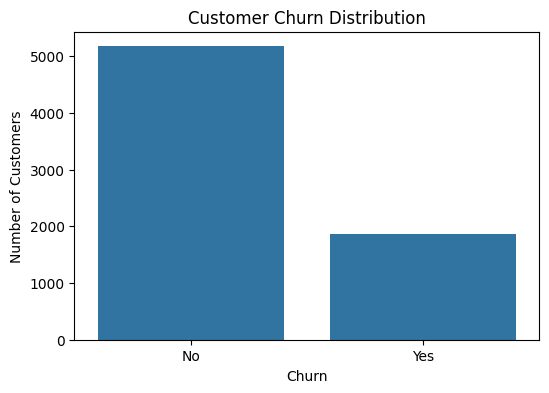

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [16]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [17]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5634
Testing samples: 1409


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [21]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[0 1 0 0 0 1 0 0 0 0]


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Model Evaluation Results
------------------------
Accuracy : 0.8048
Precision: 0.6552
Recall   : 0.5588
F1-Score : 0.6032


In [24]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[925 110]
 [165 209]]


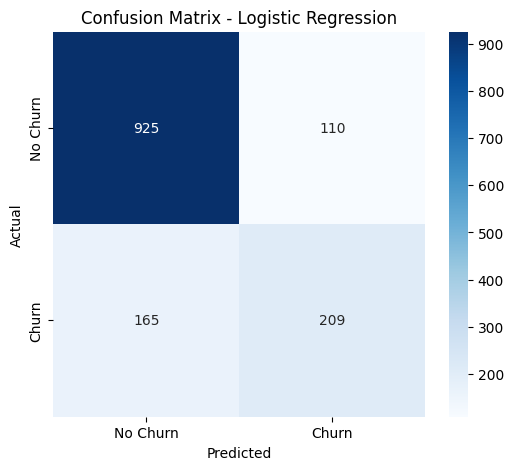

In [26]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Accuracy Scores:")
print(cv_scores)

print("\nMean Cross-Validation Accuracy:",
      round(cv_scores.mean(), 4))

print("Standard Deviation:",
      round(cv_scores.std(), 4))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-Validation Accuracy Scores:
[0.80269695 0.8105039  0.78992193 0.80894886 0.80610795]

Mean Cross-Validation Accuracy: 0.8036
Standard Deviation: 0.0074


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


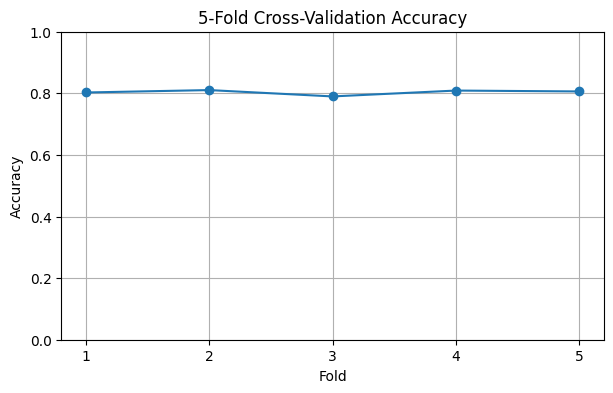

In [28]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, 6),
    cv_scores,
    marker="o"
)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.grid(True)

plt.show()

In [29]:
# Get the trained preprocessing step
trained_preprocessor = model.named_steps["preprocessor"]

# Get feature names after encoding
feature_names = trained_preprocessor.get_feature_names_out()

print("Number of model features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of model features: 45

First 20 features:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service']


In [30]:
# Get the trained Logistic Regression model
logistic_model = model.named_steps["classifier"]

coefficients = logistic_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
38,cat__Contract_Two year,-0.726515,0.726515
36,cat__Contract_Month-to-month,0.633378,0.633378
15,cat__InternetService_DSL,-0.389714,0.389714
16,cat__InternetService_Fiber optic,0.368088,0.368088
39,cat__PaperlessBilling_No,-0.262386,0.262386
12,cat__MultipleLines_No,-0.247880,0.247880
43,cat__PaymentMethod_Electronic check,0.238539,0.238539
20,cat__OnlineSecurity_Yes,-0.227438,0.227438
11,cat__PhoneService_Yes,-0.216991,0.216991
18,cat__OnlineSecurity_No,0.205812,0.205812


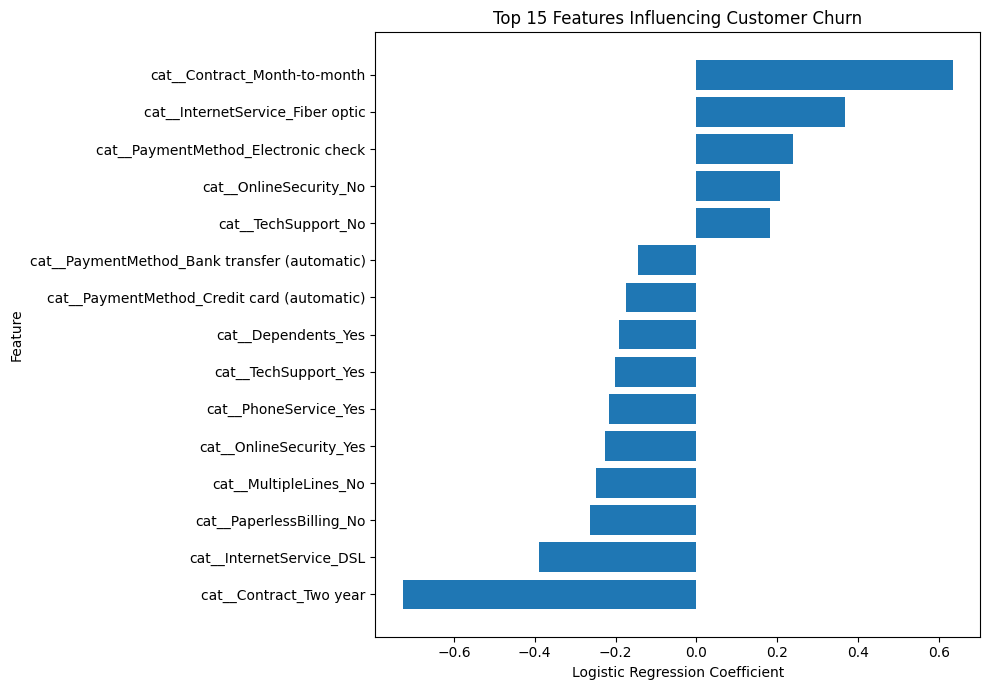

In [31]:
top_features = feature_importance.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top 15 Features Influencing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [32]:
comparison = pd.DataFrame({
    "Actual Churn": y_test.values,
    "Predicted Churn": y_pred
})

print(comparison.head(20))

    Actual Churn  Predicted Churn
0              0                0
1              0                1
2              0                0
3              0                0
4              0                0
5              0                1
6              0                0
7              0                0
8              0                0
9              1                0
10             0                0
11             0                0
12             0                0
13             1                1
14             0                0
15             0                0
16             0                0
17             0                1
18             0                0
19             0                0


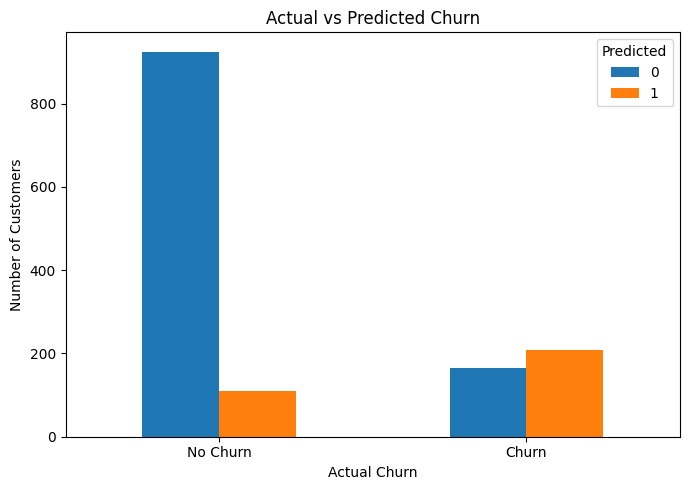

In [33]:
comparison_counts = pd.crosstab(
    comparison["Actual Churn"],
    comparison["Predicted Churn"]
)

comparison_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Actual vs Predicted Churn")
plt.xlabel("Actual Churn")
plt.ylabel("Number of Customers")
plt.xticks(
    ticks=[0, 1],
    labels=["No Churn", "Churn"],
    rotation=0
)

plt.legend(title="Predicted")
plt.tight_layout()
plt.show()

In [34]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("Customer Churn Percentage:")
print(churn_percentage)

Customer Churn Percentage:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


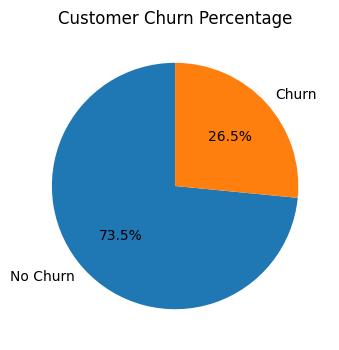

In [35]:
plt.figure(figsize=(6, 4))

plt.pie(
    churn_percentage,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")
plt.show()

In [36]:
df.to_csv("Telco_Customer_Churn_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [43]:
# ==========================================
# RANDOM FOREST MODEL - COMPLETE SECTION
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Create Random Forest pipeline
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

# Display results
print("Random Forest Model Results")
print("===========================")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

Random Forest Model Results
Accuracy : 0.785
Precision: 0.6246
Recall   : 0.4759
F1-Score : 0.5402

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [44]:
# Random Forest Confusion Matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[928 107]
 [196 178]]


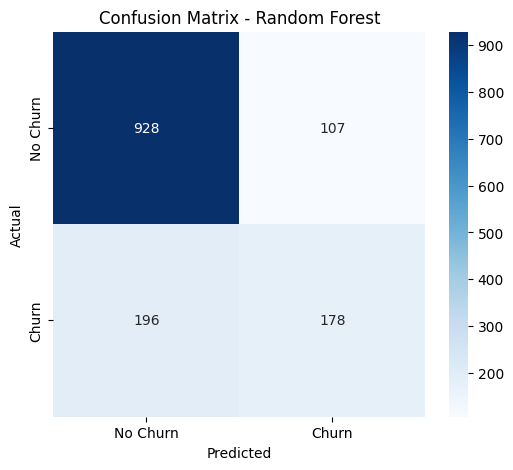

In [45]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1-Score": [
        f1,
        rf_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.804826,0.655172,0.558824,0.603175
1,Random Forest,0.784954,0.624561,0.475936,0.540212


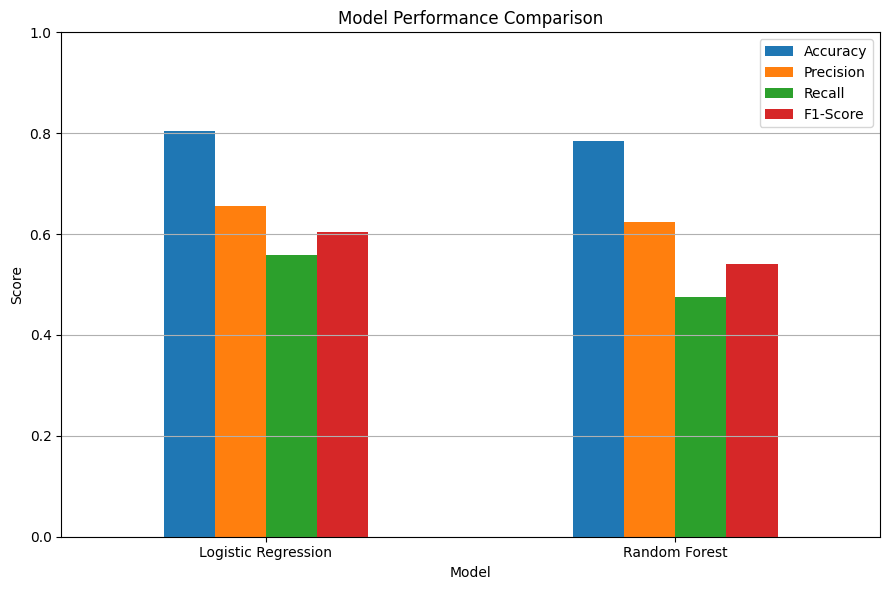

In [47]:
model_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [48]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Random Forest 5-Fold Cross-Validation Scores:")
print(rf_cv_scores)

print("\nMean Cross-Validation Accuracy:",
      round(rf_cv_scores.mean(), 4))

print("Standard Deviation:",
      round(rf_cv_scores.std(), 4))

Random Forest 5-Fold Cross-Validation Scores:
[0.79134138 0.78992193 0.76579134 0.79119318 0.796875  ]

Mean Cross-Validation Accuracy: 0.787
Standard Deviation: 0.0109


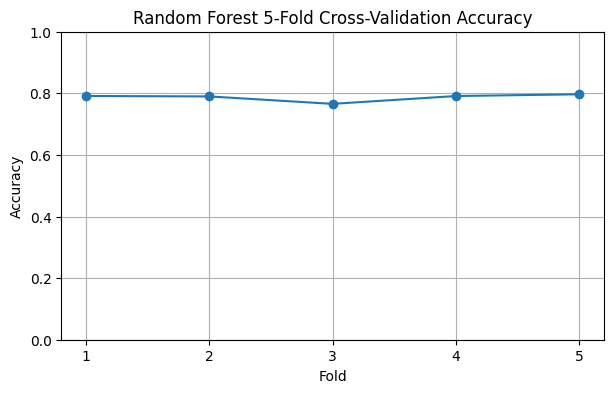

In [49]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, 6),
    rf_cv_scores,
    marker="o"
)

plt.title("Random Forest 5-Fold Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.grid(True)

plt.show()

In [50]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

rf_feature_names = rf_preprocessor.get_feature_names_out()

rf_importance = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_classifier.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
3,num__TotalCharges,0.142966
1,num__tenure,0.130728
2,num__MonthlyCharges,0.122605
36,cat__Contract_Month-to-month,0.069657
18,cat__OnlineSecurity_No,0.039620
38,cat__Contract_Two year,0.034687
27,cat__TechSupport_No,0.034413
43,cat__PaymentMethod_Electronic check,0.029161
16,cat__InternetService_Fiber optic,0.027392
21,cat__OnlineBackup_No,0.017552


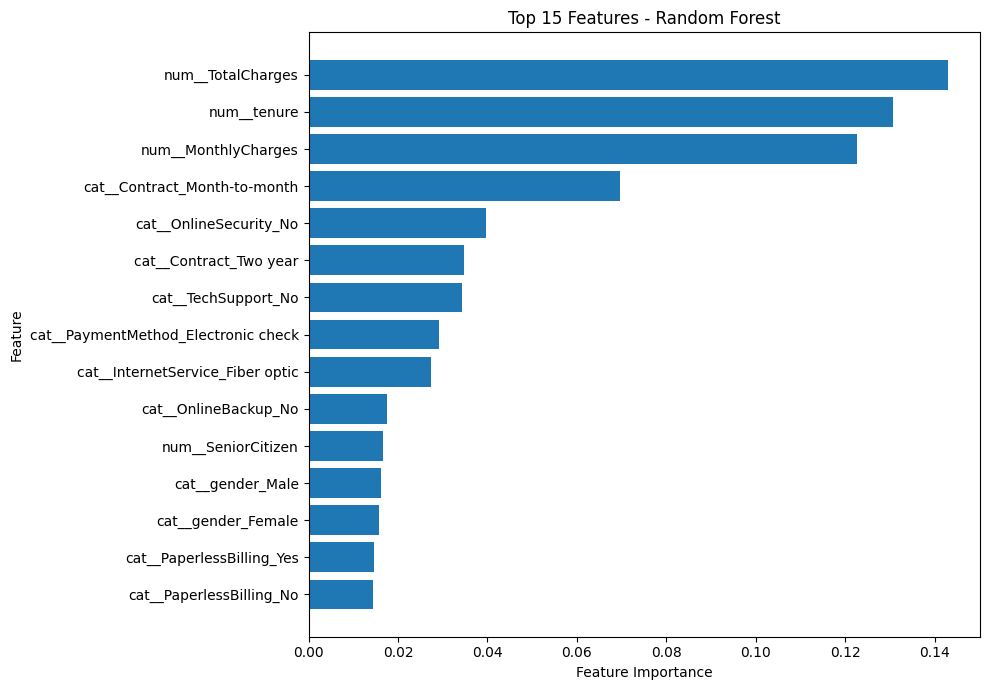

In [51]:
top_rf_features = rf_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf_features["Feature"],
    top_rf_features["Importance"]
)

plt.title("Top 15 Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()